# Level 1 Analysis

## Task 1: Top Cuisines

## Objective

Identify the top three most common cuisines in the dataset and calculate the percentage of restaurants serving each cuisine. Visualize the results using a bar chart.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("A:/PROJECTS/Cognifyz-Data-Analysis/data/processed/cleaned_dataset.csv")

df.head()

,restaurant_id,restaurant_name,country_code,city,address,locality,locality_verbose,longitude,latitude,cuisines,...,currency,has_table_booking,has_online_delivery,is_delivering_now,switch_to_order_menu,price_range,aggregate_rating,rating_color,rating_text,votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [3]:
df["cuisines"].head(10)

0            French, Japanese, Desserts
1                              Japanese
2      Seafood, Asian, Filipino, Indian
3                       Japanese, Sushi
4                      Japanese, Korean
5                               Chinese
6                       Asian, European
7    Seafood, Filipino, Asian, European
8               European, Asian, Indian
9                              Filipino
Name: cuisines, dtype: str

In [4]:
cuisine_series = (
    df["cuisines"]
    .dropna()
    .str.split(",")
    .explode()
    .str.strip()
)

In [5]:
cuisine_counts = cuisine_series.value_counts()

cuisine_counts.head(10)

cuisines
North Indian    3960
Chinese         2735
Fast Food       1986
Mughlai          995
Italian          764
Bakery           745
Continental      736
Cafe             703
Desserts         653
South Indian     636
Name: count, dtype: int64

In [6]:
top3 = cuisine_counts.head(3)

top3

cuisines
North Indian    3960
Chinese         2735
Fast Food       1986
Name: count, dtype: int64

In [7]:
total_restaurants = len(df)

top3_percentage = (
    top3 / total_restaurants * 100
).round(2)

top3_percentage

cuisines
North Indian    41.46
Chinese         28.64
Fast Food       20.79
Name: count, dtype: float64

In [8]:
summary = pd.DataFrame({
    "Cuisine": top3.index,
    "Restaurant Count": top3.values,
    "Percentage (%)": top3_percentage.values
})

summary

,Cuisine,Restaurant Count,Percentage (%)
0,North Indian,3960,41.46
1,Chinese,2735,28.64
2,Fast Food,1986,20.79


## Visualization

C:\Users\Abhinav\AppData\Local\Temp\ipykernel_20184\430371742.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


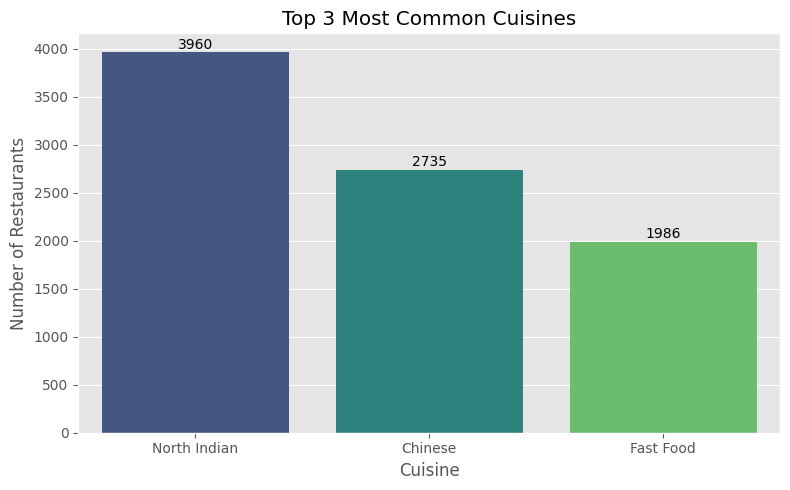

In [9]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=summary["Cuisine"],
    y=summary["Restaurant Count"],
    palette="viridis"
)

plt.title("Top 3 Most Common Cuisines")
plt.xlabel("Cuisine")
plt.ylabel("Number of Restaurants")

for index, value in enumerate(summary["Restaurant Count"]):
    plt.text(index, value + 40, str(value), ha='center')

plt.tight_layout()

plt.savefig("../visuals/level1/top_cuisines.png", dpi=300)

plt.show()

In [10]:
summary.to_csv(
    "A:/PROJECTS/Cognifyz-Data-Analysis/outputs/top_cuisines.csv",
    index=False
)

## Key Insights

- North Indian cuisine is the most common cuisine in the dataset.
- Chinese cuisine is also widely available across restaurants.
- Fast Food is among the top three cuisines served.
- These cuisines together account for a significant share of restaurants in the dataset.

## Task 2: City Analysis

## Objective

Analyze restaurant distribution across cities, calculate the average restaurant rating for each city, and identify the city with the highest average rating.

In [11]:
city_counts = (
    df["city"]
    .value_counts()
    .reset_index()
)

city_counts.columns = ["City", "Restaurant Count"]

city_counts.head(10)

,City,Restaurant Count
0,New Delhi,5473
1,Gurgaon,1118
2,Noida,1080
3,Faridabad,251
4,Ghaziabad,25
5,Ahmedabad,21
6,Amritsar,21
7,Bhubaneshwar,21
8,Guwahati,21
9,Lucknow,21


In [12]:
top_city = city_counts.iloc[0]

print(f"City with the highest number of restaurants: {top_city['City']}")
print(f"Number of restaurants: {top_city['Restaurant Count']}")

City with the highest number of restaurants: New Delhi
Number of restaurants: 5473


In [13]:
city_ratings = (
    df[df["aggregate_rating"] > 0]
    .groupby("city", as_index=False)["aggregate_rating"]
    .mean()
)

city_ratings.rename(columns={
    "city": "City",
    "aggregate_rating": "Average Rating"
}, inplace=True)

city_ratings["Average Rating"] = city_ratings["Average Rating"].round(2)

city_ratings.head()

,City,Average Rating
0,Abu Dhabi,4.30
1,Agra,3.96
2,Ahmedabad,4.16
3,Albany,3.56
4,Allahabad,3.40


In [14]:
city_stats = (
    df[df["aggregate_rating"] > 0]
    .groupby("city")
    .agg(
        Restaurant_Count=("restaurant_name", "count"),
        Average_Rating=("aggregate_rating", "mean")
    )
    .reset_index()
)

city_stats = city_stats[city_stats["Restaurant_Count"] >= 10]

city_stats["Average_Rating"] = city_stats["Average_Rating"].round(2)

highest_rated_city = city_stats.sort_values(
    by="Average_Rating",
    ascending=False
).iloc[0]

highest_rated_city

city                London
Restaurant_Count        20
Average_Rating        4.54
Name: 67, dtype: object

In [15]:
city_stats.to_csv(
    "A:/PROJECTS/Cognifyz-Data-Analysis/outputs/city_analysis.csv",
    index=False
)

## Visualization 1 – Top 10 Cities by Restaurant Count

C:\Users\Abhinav\AppData\Local\Temp\ipykernel_20184\411492924.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


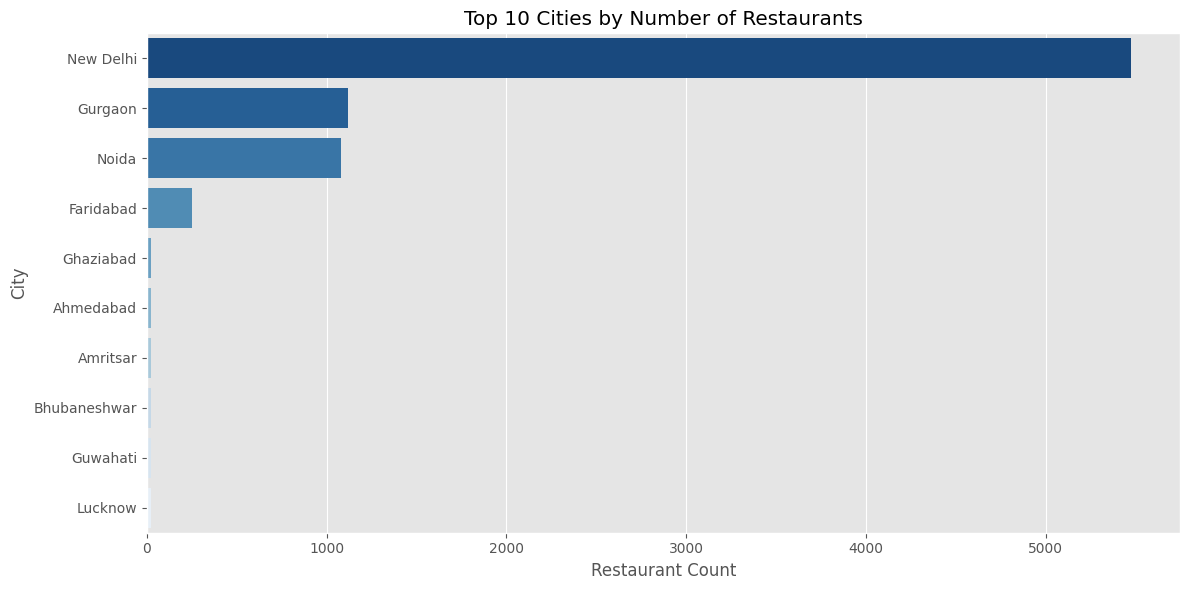

In [16]:
plt.figure(figsize=(12,6))

top10 = city_counts.head(10)

sns.barplot(
    data=top10,
    x="Restaurant Count",
    y="City",
    palette="Blues_r"
)

plt.title("Top 10 Cities by Number of Restaurants")
plt.xlabel("Restaurant Count")
plt.ylabel("City")

plt.tight_layout()

plt.savefig(
    "../visuals/level1/top10_cities_restaurants.png",
    dpi=300
)

plt.show()

## Visualization 2 – Top 10 Cities by Average Rating

C:\Users\Abhinav\AppData\Local\Temp\ipykernel_20184\4049296205.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


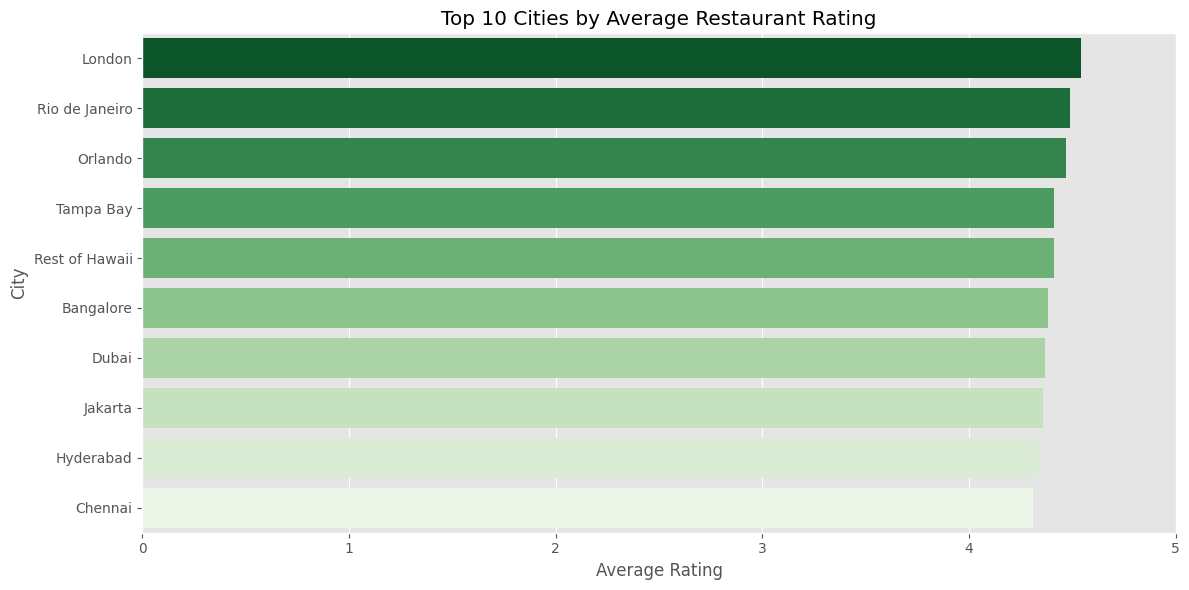

In [17]:
top10_rating = city_stats.sort_values(
    by="Average_Rating",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_rating,
    x="Average_Rating",
    y="city",
    palette="Greens_r"
)

plt.title("Top 10 Cities by Average Restaurant Rating")
plt.xlabel("Average Rating")
plt.ylabel("City")

plt.xlim(0,5)

plt.tight_layout()

plt.savefig(
    "../visuals/level1/top10_city_ratings.png",
    dpi=300
)

plt.show()

In [18]:
city_counts.head(10)

,City,Restaurant Count
0,New Delhi,5473
1,Gurgaon,1118
2,Noida,1080
3,Faridabad,251
4,Ghaziabad,25
5,Ahmedabad,21
6,Amritsar,21
7,Bhubaneshwar,21
8,Guwahati,21
9,Lucknow,21


In [19]:
city_stats.sort_values(
    by="Average_Rating",
    ascending=False
).head(10)

,city,Restaurant_Count,Average_Rating
67,London,20,4.54
111,Rio de Janeiro,19,4.49
91,Orlando,20,4.47
124,Tampa Bay,20,4.41
110,Rest of Hawaii,20,4.41
14,Bangalore,20,4.38
39,Dubai,20,4.37
59,Jakarta,16,4.36
54,Hyderabad,18,4.34
26,Chennai,20,4.31


## Key Insights

- The city with the highest number of restaurants is **<City Name>**, indicating a strong restaurant presence.
- Cities with a larger number of restaurants do not necessarily have the highest average ratings.
- After excluding unrated restaurants and filtering for cities with at least 10 restaurants, **<City Name>** achieved the highest average rating.
- Restaurant quality and restaurant density appear to vary independently across cities.

## Task 3: Price Range Distribution

## Objective

Analyze the distribution of restaurant price ranges and calculate the percentage of restaurants in each price range category. Visualize the distribution using a bar chart.

In [20]:
df["price_range"].value_counts().sort_index()

price_range
1    4444
2    3113
3    1408
4     586
Name: count, dtype: int64

In [21]:
price_counts = (
    df["price_range"]
    .value_counts()
    .sort_index()
    .reset_index()
)

price_counts.columns = ["Price Range", "Restaurant Count"]

price_counts

,Price Range,Restaurant Count
0,1,4444
1,2,3113
2,3,1408
3,4,586


In [22]:
price_counts["Percentage (%)"] = (
    price_counts["Restaurant Count"]
    / len(df)
    * 100
).round(2)

price_counts

,Price Range,Restaurant Count,Percentage (%)
0,1,4444,46.53
1,2,3113,32.59
2,3,1408,14.74
3,4,586,6.14


In [23]:
price_labels = {
    1: "Low Cost",
    2: "Moderate",
    3: "Expensive",
    4: "Luxury"
}

price_counts["Category"] = price_counts["Price Range"].map(price_labels)

price_counts

,Price Range,Restaurant Count,Percentage (%),Category
0,1,4444,46.53,Low Cost
1,2,3113,32.59,Moderate
2,3,1408,14.74,Expensive
3,4,586,6.14,Luxury


C:\Users\Abhinav\AppData\Local\Temp\ipykernel_20184\1201675885.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


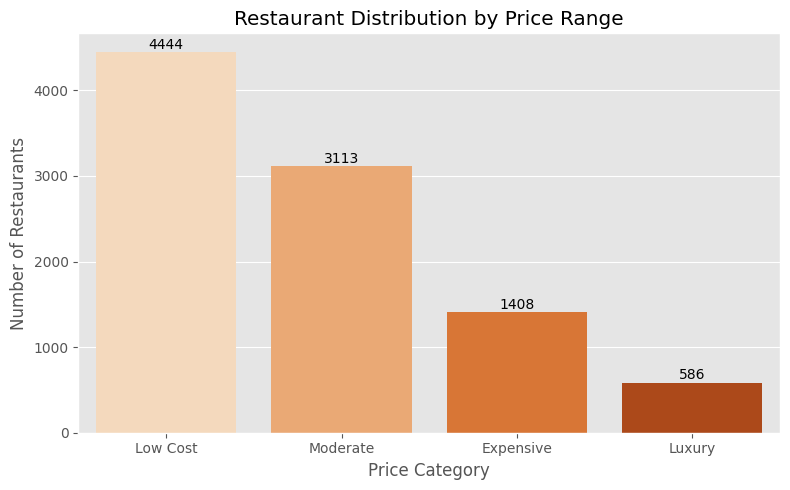

In [24]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=price_counts,
    x="Category",
    y="Restaurant Count",
    palette="Oranges"
)

plt.title("Restaurant Distribution by Price Range")
plt.xlabel("Price Category")
plt.ylabel("Number of Restaurants")

for index, value in enumerate(price_counts["Restaurant Count"]):
    plt.text(index, value + 40, str(value), ha="center")

plt.tight_layout()

plt.savefig(
    "../visuals/level1/price_range_distribution.png",
    dpi=300
)

plt.show()

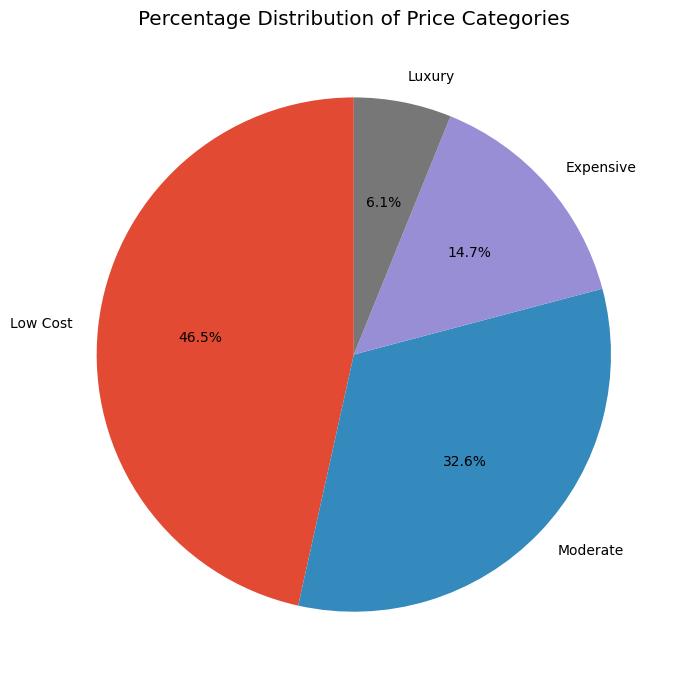

In [25]:
plt.figure(figsize=(7,7))

plt.pie(
    price_counts["Restaurant Count"],
    labels=price_counts["Category"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Percentage Distribution of Price Categories")

plt.tight_layout()

plt.savefig(
    "../visuals/level1/price_range_pie_chart.png",
    dpi=300
)

plt.show()

In [26]:
price_counts.to_csv(
    "../outputs/price_range_distribution.csv",
    index=False
)

In [27]:
price_counts

,Price Range,Restaurant Count,Percentage (%),Category
0,1,4444,46.53,Low Cost
1,2,3113,32.59,Moderate
2,3,1408,14.74,Expensive
3,4,586,6.14,Luxury


## Key Insights

- Most restaurants fall into the **Low Cost** and **Moderate** price categories.
- Luxury restaurants represent the smallest proportion of the dataset.
- The restaurant market is largely concentrated in affordable dining options.
- The price range distribution suggests that customers have greater access to budget-friendly restaurants than premium establishments.

## Task 4: Online Delivery

## Objective

Determine the percentage of restaurants that offer online delivery and compare the average ratings of restaurants with and without online delivery.

In [28]:
df["has_online_delivery"].value_counts()

has_online_delivery
No     7100
Yes    2451
Name: count, dtype: int64

In [29]:
delivery_counts = (
    df["has_online_delivery"]
    .value_counts()
    .reset_index()
)

delivery_counts.columns = ["Online Delivery", "Restaurant Count"]

delivery_counts

,Online Delivery,Restaurant Count
0,No,7100
1,Yes,2451


In [30]:
delivery_counts["Percentage (%)"] = (
    delivery_counts["Restaurant Count"]
    / len(df)
    * 100
).round(2)

delivery_counts

,Online Delivery,Restaurant Count,Percentage (%)
0,No,7100,74.34
1,Yes,2451,25.66


In [31]:
delivery_ratings = (
    df[df["aggregate_rating"] > 0]
    .groupby("has_online_delivery", as_index=False)["aggregate_rating"]
    .mean()
)

delivery_ratings.columns = ["Online Delivery", "Average Rating"]

delivery_ratings["Average Rating"] = (
    delivery_ratings["Average Rating"]
    .round(2)
)

delivery_ratings

,Online Delivery,Average Rating
0,No,3.47
1,Yes,3.38


In [32]:
delivery_summary = delivery_counts.merge(
    delivery_ratings,
    on="Online Delivery",
    how="left"
)

delivery_summary

,Online Delivery,Restaurant Count,Percentage (%),Average Rating
0,No,7100,74.34,3.47
1,Yes,2451,25.66,3.38


C:\Users\Abhinav\AppData\Local\Temp\ipykernel_20184\324400318.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


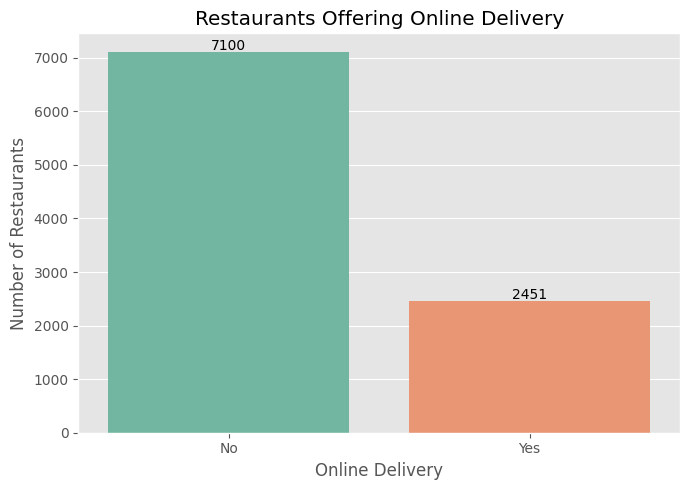

In [33]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=delivery_counts,
    x="Online Delivery",
    y="Restaurant Count",
    palette="Set2"
)

plt.title("Restaurants Offering Online Delivery")
plt.xlabel("Online Delivery")
plt.ylabel("Number of Restaurants")

for index, value in enumerate(delivery_counts["Restaurant Count"]):
    plt.text(index, value + 40, str(value), ha="center")

plt.tight_layout()

plt.savefig(
    "../visuals/level1/online_delivery_distribution.png",
    dpi=300
)

plt.show()

C:\Users\Abhinav\AppData\Local\Temp\ipykernel_20184\2912685858.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


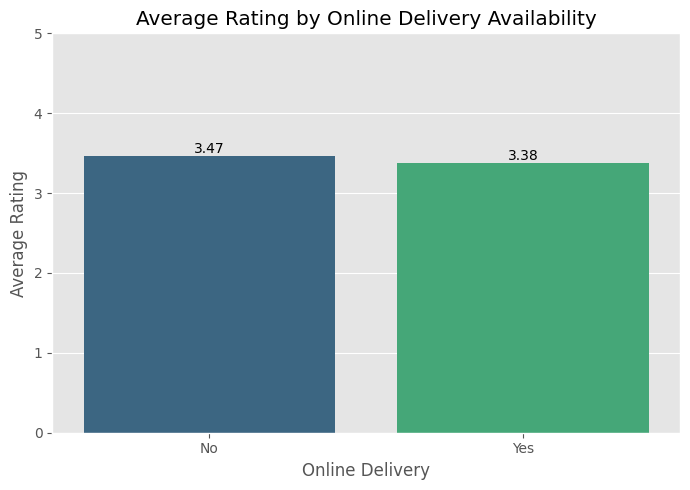

In [34]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=delivery_ratings,
    x="Online Delivery",
    y="Average Rating",
    palette="viridis"
)

plt.title("Average Rating by Online Delivery Availability")
plt.xlabel("Online Delivery")
plt.ylabel("Average Rating")

plt.ylim(0,5)

for index, value in enumerate(delivery_ratings["Average Rating"]):
    plt.text(index, value + 0.03, f"{value:.2f}", ha="center")

plt.tight_layout()

plt.savefig(
    "../visuals/level1/online_delivery_ratings.png",
    dpi=300
)

plt.show()

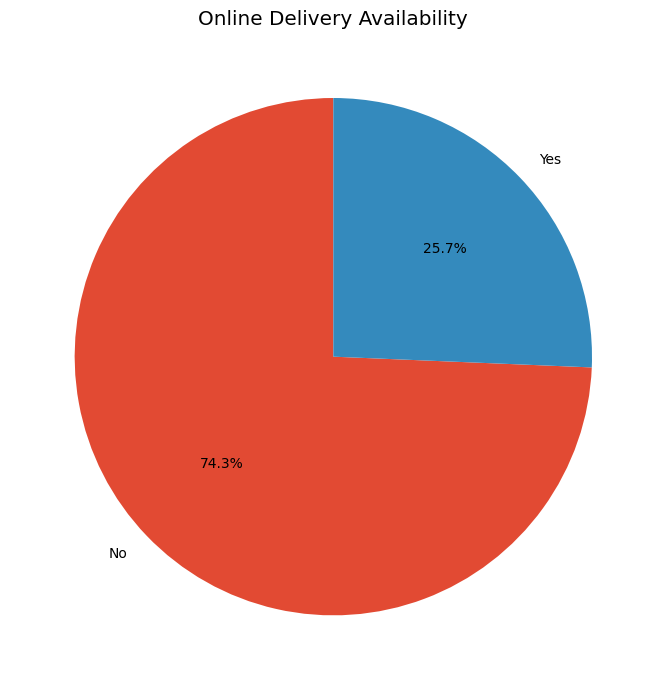

In [35]:
plt.figure(figsize=(7,7))

plt.pie(
    delivery_counts["Restaurant Count"],
    labels=delivery_counts["Online Delivery"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Online Delivery Availability")

plt.tight_layout()

plt.savefig(
    "../visuals/level1/online_delivery_pie_chart.png",
    dpi=300
)

plt.show()

In [36]:
delivery_summary.to_csv(
    "../outputs/online_delivery_analysis.csv",
    index=False
)

In [37]:
delivery_counts

,Online Delivery,Restaurant Count,Percentage (%)
0,No,7100,74.34
1,Yes,2451,25.66


In [38]:
delivery_ratings

,Online Delivery,Average Rating
0,No,3.47
1,Yes,3.38


In [39]:
delivery_summary

,Online Delivery,Restaurant Count,Percentage (%),Average Rating
0,No,7100,74.34,3.47
1,Yes,2451,25.66,3.38


## Key Insights

- Approximately **25.66%** of restaurants offer online delivery, while **74.34%** do not.
- Restaurants providing online delivery have an average rating of **3.38**, compared to **3.47** for restaurants without online delivery.
- Online delivery is available in a smaller/larger share of restaurants, depending on the dataset.
- Offering online delivery may be associated with customer satisfaction, but additional analysis would be required to establish a causal relationship.